# Week 1 — Exploratory Data Analysis & Data Cleaning

**Project:** AI-Powered Task Management System — Hospital Length of Stay Prediction
**Dataset:** AV Healthcare Analytics II ([Kaggle](https://www.kaggle.com/datasets/nehaprabhavalkar/av-healthcare-analytics-ii))
**Prepared by:** Vijayasiva

**Goals of this notebook**
1. Understand the structure and contents of the dataset (EDA)
2. Handle missing values, duplicate records, and inconsistent data
3. Visualize distributions and relationships (histograms, bar charts, correlation heatmap, count plots)
4. Save a cleaned dataset ready for NLP/feature engineering in Week 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 90

df = pd.read_csv("../data/raw/train.csv")
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
df.head()

Rows: 318438 | Columns: 18


,case_id,Hospital,Hospital_type,Hospital_city,Hospital_region,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility,Bed_Grade,patientid,City_Code_Patient,Type of Admission,Illness_Severity,Patient_Visitors,Age,Admission_Deposit,Stay_Days
0,1,8,2,3,2,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911.0,0-10
1,2,2,2,5,2,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954.0,41-50
2,3,10,4,1,0,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745.0,31-40
3,4,26,1,2,1,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272.0,41-50
4,5,26,1,2,1,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558.0,41-50


## 1. Dataset Overview

First we look at the column types, value ranges and basic statistics.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            318438 non-null  int64  
 1   Hospital                           318438 non-null  int64  
 2   Hospital_type                      318438 non-null  int64  
 3   Hospital_city                      318438 non-null  int64  
 4   Hospital_region                    318438 non-null  int64  
 5   Available_Extra_Rooms_in_Hospital  318438 non-null  int64  
 6   Department                         318438 non-null  object 
 7   Ward_Type                          318438 non-null  object 
 8   Ward_Facility                      318438 non-null  object 
 9   Bed_Grade                          318325 non-null  float64
 10  patientid                          318438 non-null  int64  
 11  City_Code_Patient                  3139

In [3]:
df.describe(include="all").T.round(2)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,318438.0,NaN,NaN,NaN,159219.5,91925.276848,1.0,79610.25,159219.5,238828.75,318438.0
Hospital,318438.0,NaN,NaN,NaN,18.318841,8.633755,1.0,11.0,19.0,26.0,32.0
Hospital_type,318438.0,NaN,NaN,NaN,1.256841,1.535712,0.0,0.0,1.0,2.0,6.0
Hospital_city,318438.0,NaN,NaN,NaN,4.771717,3.102535,1.0,2.0,5.0,7.0,13.0
Hospital_region,318438.0,NaN,NaN,NaN,0.778098,0.752527,0.0,0.0,1.0,1.0,2.0
Available_Extra_Rooms_in_Hospital,318438.0,NaN,NaN,NaN,3.197627,1.168171,0.0,2.0,3.0,4.0,24.0
Department,318438,5,gynecology,249486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ward_Type,318438,6,R,127947,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ward_Facility,318438,6,F,112753,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bed_Grade,318325.0,NaN,NaN,NaN,2.625807,0.873146,1.0,2.0,3.0,3.0,4.0


**Observations**
- 318,438 admission records, 18 columns.
- `case_id` is a unique row identifier; `patientid` repeats — one patient can have several admissions.
- `Age` and the target `Stay_Days` are stored as string ranges (e.g. `"21-30"`), so they are ordinal categories, not numbers.
- The column name `Type of Admission` contains spaces — inconsistent with the other snake_case names.

## 2. Missing Values

                   missing_count  missing_%
City_Code_Patient           4532       1.42
Bed_Grade                    113       0.04


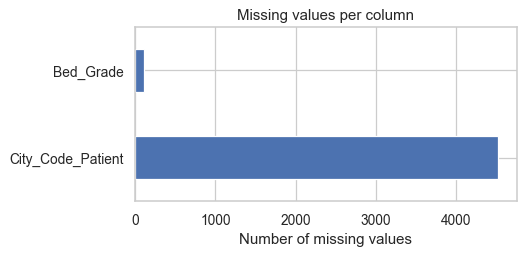

In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
print(missing_table)

fig, ax = plt.subplots(figsize=(6, 3))
missing.plot.barh(ax=ax, color="#4c72b0")
ax.set_title("Missing values per column")
ax.set_xlabel("Number of missing values")
plt.tight_layout()
plt.show()

**Observations**
- Only 2 of 18 columns have missing data, and both are small fractions of the dataset:
  - `City_Code_Patient`: 4,532 missing (~1.4%)
  - `Bed_Grade`: 113 missing (~0.04%)
- Both are categorical codes, so we will impute with the **mode** (most frequent value) rather than a mean, and we will do it *after* the duplicate check so imputation does not create artificial duplicates.

## 3. Duplicate Records

In [5]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate case_id:", df["case_id"].duplicated().sum())
print("Unique patients:", df["patientid"].nunique(),
      "(patients appear in up to", df["patientid"].value_counts().max(), "cases)")

# Duplicates ignoring the identifier columns — same patient, identical admission details
dup_wo_id = df.drop(columns=["case_id"]).duplicated().sum()
print("Duplicates ignoring case_id:", dup_wo_id)

Exact duplicate rows: 0
Duplicate case_id: 0
Unique patients: 92017 (patients appear in up to 50 cases)


Duplicates ignoring case_id: 65


**Observations**
- There are **no exact duplicate rows** and every `case_id` is unique.
- A patient appearing multiple times is *expected* (multiple admissions), not a data error, so those rows are kept.

## 4. Inconsistent Data Checks

In [6]:
# 4.1 Column-name consistency: rename the one column with spaces
df = df.rename(columns={"Type of Admission": "Admission_Type"})

# 4.2 Check categorical columns for unexpected/inconsistent labels
for col in ["Department", "Ward_Type", "Ward_Facility", "Admission_Type",
            "Illness_Severity", "Age", "Stay_Days"]:
    print(f"{col:18s}: {sorted(df[col].dropna().unique().tolist())}")

Department        : ['TB & Chest disease', 'anesthesia', 'gynecology', 'radiotherapy', 'surgery']
Ward_Type         : ['P', 'Q', 'R', 'S', 'T', 'U']
Ward_Facility     : ['A', 'B', 'C', 'D', 'E', 'F']
Admission_Type    : ['Emergency', 'Trauma', 'Urgent']
Illness_Severity  : ['Extreme', 'Minor', 'Moderate']
Age               : ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100']


Stay_Days         : ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100', 'More than 100 Days']


In [7]:
# 4.3 Range sanity checks on numeric columns
checks = {
    "Available_Extra_Rooms_in_Hospital negative": (df["Available_Extra_Rooms_in_Hospital"] < 0).sum(),
    "Patient_Visitors negative": (df["Patient_Visitors"] < 0).sum(),
    "Admission_Deposit non-positive": (df["Admission_Deposit"] <= 0).sum(),
    "Bed_Grade outside 1-4": (~df["Bed_Grade"].dropna().between(1, 4)).sum(),
}
for name, count in checks.items():
    print(f"{name}: {count}")

Available_Extra_Rooms_in_Hospital negative: 0
Patient_Visitors negative: 0
Admission_Deposit non-positive: 0
Bed_Grade outside 1-4: 0


**Observations**
- All category labels are clean and consistent — no typos, mixed casing, or stray whitespace.
- Numeric columns pass their sanity checks (no negative room counts or visitor counts, all deposits positive, bed grades within 1–4).
- The only inconsistency found was the column name `Type of Admission`, which we renamed to `Admission_Type` to match the other columns.

## 5. Target Variable — `Stay_Days`

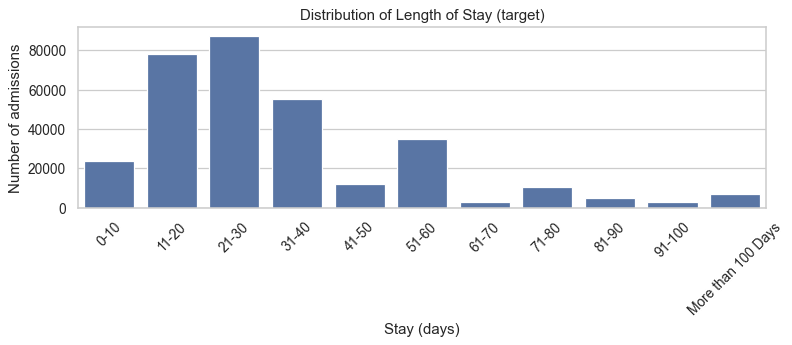

Stay_Days
0-10                   7.4
11-20                 24.5
21-30                 27.5
31-40                 17.3
41-50                  3.7
51-60                 11.0
61-70                  0.9
71-80                  3.2
81-90                  1.5
91-100                 0.9
More than 100 Days     2.1
Name: proportion, dtype: float64

In [8]:
stay_order = ["0-10", "11-20", "21-30", "31-40", "41-50", "51-60",
              "61-70", "71-80", "81-90", "91-100", "More than 100 Days"]

fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(data=df, x="Stay_Days", order=stay_order, color="#4c72b0", ax=ax)
ax.set_title("Distribution of Length of Stay (target)")
ax.set_xlabel("Stay (days)")
ax.set_ylabel("Number of admissions")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

(df["Stay_Days"].value_counts(normalize=True).reindex(stay_order) * 100).round(1)

**Observations**
- The target has **11 classes and is clearly imbalanced**: 21-30 days (27.5%) and 11-20 days (24.5%) dominate, while 61-70 and 91-100 days are each under 1%.
- Week 3 modelling must use stratified train/validation splits and consider class weights.

## 6. Categorical Features — Count Plots

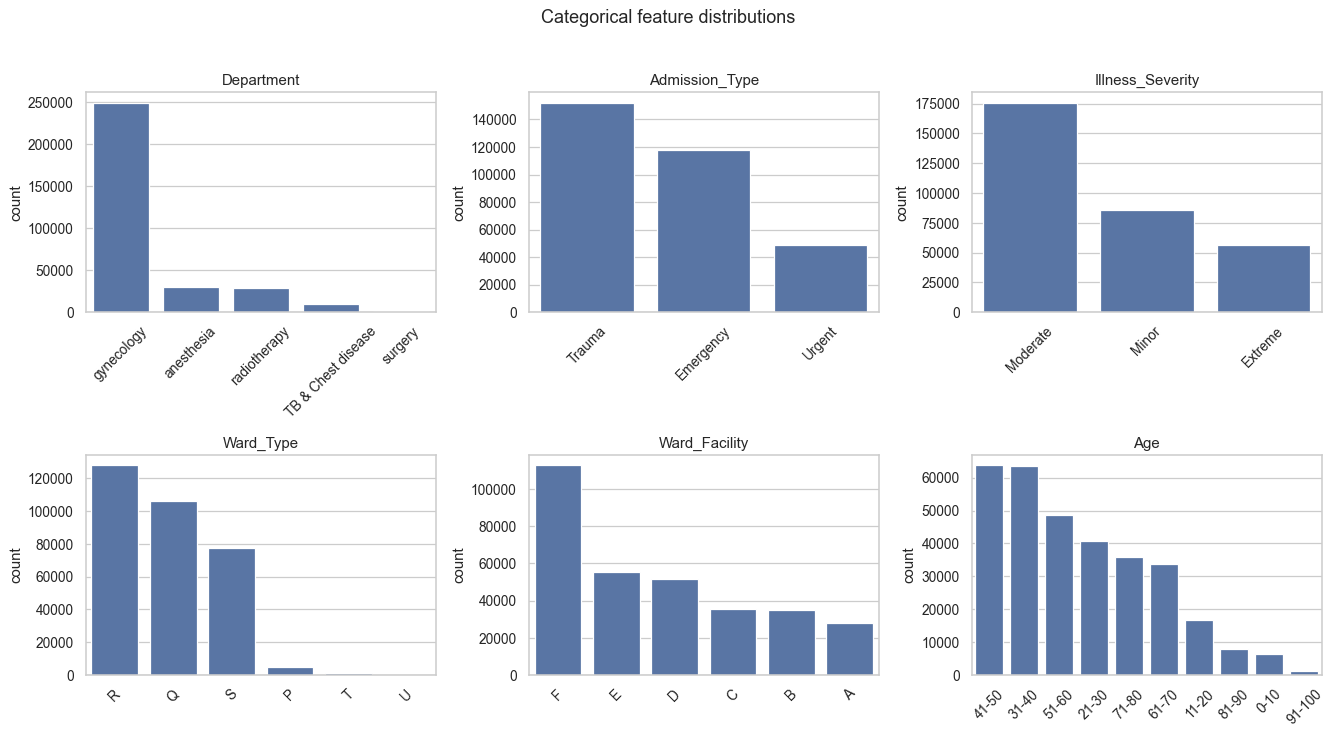

In [9]:
cat_cols = ["Department", "Admission_Type", "Illness_Severity", "Ward_Type", "Ward_Facility", "Age"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, color="#4c72b0", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
plt.suptitle("Categorical feature distributions", y=1.02)
plt.tight_layout()
plt.show()

**Observations**
- **Department** is dominated by gynecology (~78% of admissions); TB & Chest disease and surgery are rare.
- **Admission_Type**: Trauma is the most common, followed by Emergency, then Urgent.
- **Illness_Severity**: most admissions are Moderate; Extreme is the smallest group.
- **Age** is roughly bell-shaped, centred on the 31–50 bands; very young and very old patients are rare.

## 7. Numeric Features — Histograms

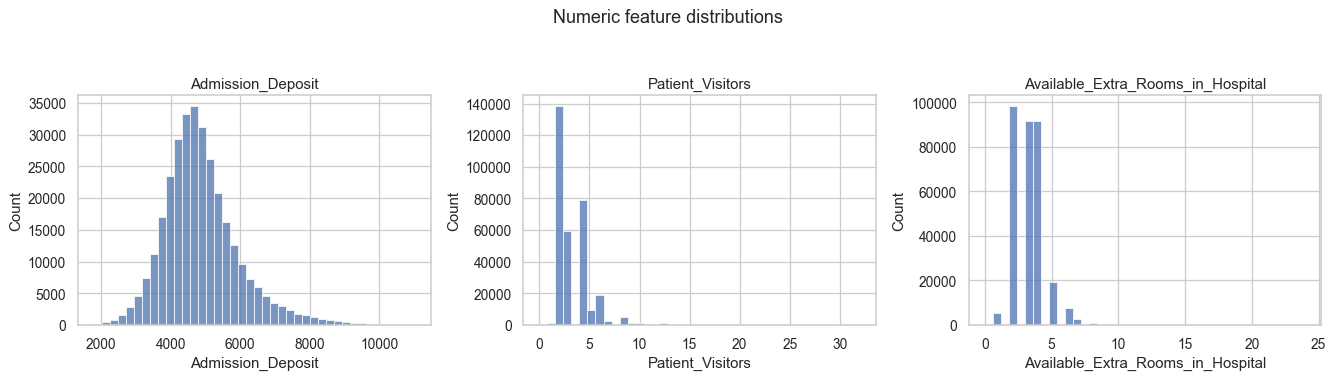

In [10]:
num_cols = ["Admission_Deposit", "Patient_Visitors", "Available_Extra_Rooms_in_Hospital"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], bins=40, color="#4c72b0", ax=ax)
    ax.set_title(col)
plt.suptitle("Numeric feature distributions", y=1.05)
plt.tight_layout()
plt.show()

**Observations**
- **Admission_Deposit** is roughly normal around ~4,900 with a mild right tail — no impossible values.
- **Patient_Visitors** and **Available_Extra_Rooms_in_Hospital** are right-skewed counts with rare high values (up to 32 visitors / 24 rooms). These look like genuine rare events rather than errors, so they are kept.

## 8. Correlation Heatmap

`Age` and `Stay_Days` are ordinal ranges, so we map them to their rank order to include them in the correlation analysis.

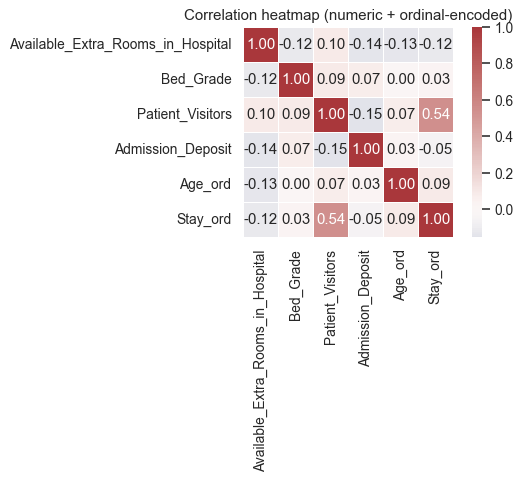

In [11]:
df_corr = df.copy()
age_order = ["0-10", "11-20", "21-30", "31-40", "41-50",
             "51-60", "61-70", "71-80", "81-90", "91-100"]
df_corr["Age_ord"] = df_corr["Age"].map({v: i for i, v in enumerate(age_order)})
df_corr["Stay_ord"] = df_corr["Stay_Days"].map({v: i for i, v in enumerate(stay_order)})

corr_cols = ["Available_Extra_Rooms_in_Hospital", "Bed_Grade", "Patient_Visitors",
             "Admission_Deposit", "Age_ord", "Stay_ord"]
corr = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation heatmap (numeric + ordinal-encoded)")
plt.tight_layout()
plt.show()

**Observations**
- **Patient_Visitors has the strongest positive correlation with length of stay** (~0.5) — patients with more visitors tend to stay longer.
- `Admission_Deposit` is weakly *negatively* correlated with stay, and `Available_Extra_Rooms_in_Hospital` also correlates negatively.
- No feature pair is highly collinear, so all features can be kept for modelling.

## 9. Bivariate Analysis — Features vs Target

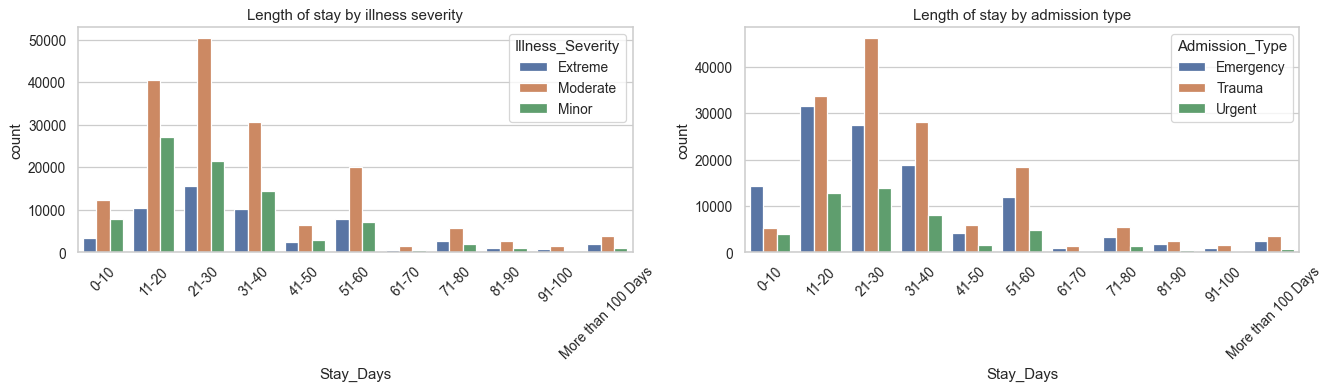

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.countplot(data=df, x="Stay_Days", hue="Illness_Severity", order=stay_order, ax=axes[0])
axes[0].set_title("Length of stay by illness severity")
axes[0].tick_params(axis="x", rotation=45)
sns.countplot(data=df, x="Stay_Days", hue="Admission_Type", order=stay_order, ax=axes[1])
axes[1].set_title("Length of stay by admission type")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Observations**
- **Extreme-severity** admissions make up a visibly larger share of the long-stay classes, while **Minor** cases concentrate in short stays — severity is predictive.
- **Trauma** admissions skew slightly longer than Emergency ones. These two features should be ordinal/one-hot encoded for the model.

## 10. Data Cleaning

In [13]:
df_clean = df.copy()

# Impute the two columns with missing values using the mode (categorical codes)
bed_mode = df_clean["Bed_Grade"].mode()[0]
city_mode = df_clean["City_Code_Patient"].mode()[0]
df_clean["Bed_Grade"] = df_clean["Bed_Grade"].fillna(bed_mode)
df_clean["City_Code_Patient"] = df_clean["City_Code_Patient"].fillna(city_mode)

# The codes are whole numbers — store them as integers now that NaNs are gone
df_clean["Bed_Grade"] = df_clean["Bed_Grade"].astype(int)
df_clean["City_Code_Patient"] = df_clean["City_Code_Patient"].astype(int)

print("Remaining missing values:", df_clean.isna().sum().sum())
print("Shape after cleaning:", df_clean.shape)

Remaining missing values: 0
Shape after cleaning: (318438, 18)


In [14]:
import os
os.makedirs("../data/processed", exist_ok=True)
df_clean.to_csv("../data/processed/train_clean.csv", index=False)
print("Saved cleaned dataset to data/processed/train_clean.csv")

Saved cleaned dataset to data/processed/train_clean.csv


## 11. Conclusions

**Data quality**
- The dataset is large (318,438 rows) and in very good shape: no duplicate records, clean and consistent category labels, and only ~1.4% missing data confined to two columns, both imputed with their mode.
- The one structural inconsistency (`Type of Admission` column name) was fixed by renaming to `Admission_Type`.

**Key findings from EDA**
1. The target `Stay_Days` is **imbalanced** across its 11 classes — stratified splitting and class weighting will be needed in modelling.
2. **Patient_Visitors** is the strongest single predictor of stay length (positive correlation ≈ 0.5).
3. **Illness_Severity** and **Admission_Type** clearly shift the stay distribution, confirming they are useful categorical predictors.
4. Gynecology dominates the Department column; rare categories may need grouping during feature engineering.
5. `Age` and `Stay_Days` are ordinal string ranges and must be ordinal-encoded in Week 2.

**Deliverables**
- Cleaned dataset: `data/processed/train_clean.csv` (318,438 rows × 18 columns, zero missing values)
- This notebook with all EDA visualizations and observations.